# Equivariant Neural Networks (Equ-NN) for 2+1D compact U(1) pure gauge  
### A PyTorch VMC mini-project (with coding TODOs)

**Audience.** You know U(1) lattice gauge theory and NumPy. You’re learning PyTorch and want a structured path toward simulating QFTs.

**Goal.** Build a gauge-invariant neural wavefunction \(\psi(\theta)\) on an \(L\times L\) periodic lattice, sample \(|\psi|^2\) with Metropolis–Hastings, estimate the Hamiltonian expectation via a stable finite-difference local energy, and (optionally) train with a basic VMC gradient.

**Notebook design.**  
- Every non-trivial coding step has a **TODO block** for you to fill in.  
- Each section has **sanity checks** (asserts + small diagnostic prints).  
- Keep \(L=2\) initially for fast iteration.

> Tip: run cells top-to-bottom. If an assert fails, fix the nearest TODO above it.


In [ ]:
import torch
import random
import numpy as np
import os

def set_seed(seed_value=42):
    """Set seeds for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value) # for multi-GPU setups
    os.environ['PYTHONHASHSEED'] = str(seed_value)

    # For deterministic CuDNN behavior (optional, may impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # torch.backends.cudnn.enabled = False # can be set to True/False based on needs

# Call the function with a chosen seed
set_seed(42)


## 0. Setup: imports, device, dtype

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

TWOPI = 2.0 * math.pi

# Recommended: start on CPU for debugging; switch to CUDA later if available.
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float64

print("device:", device)
print("dtype:", dtype)
torch.set_default_dtype(dtype)


device: cpu
dtype: torch.float64


## 1. Data model: link angles on a periodic lattice

We represent link angles as a PyTorch tensor:
- `theta.shape == (B, 2, L, L)`
- direction index `0` is x-links, `1` is y-links
- angles are in \([0,2\pi)\)

We'll use periodic boundary conditions.


In [ ]:
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
B, L = 8, 2
theta = (TWOPI * torch.rand(B, 2, L, L, device=device, dtype=dtype)) % TWOPI

assert theta.shape == (B, 2, L, L)
assert float(theta.min()) >= 0.0 - 1e-12
assert float(theta.max()) <= TWOPI + 1e-12

print("theta.shape =", theta.shape)
print("theta range ~", (float(theta.min()), float(theta.max())))


theta.shape = torch.Size([8, 2, 2, 2])
theta range ~ (0.06965155810677741, 6.273356225035479)


## 2. Periodic shifts and plaquette angle \(\phi(v)\)

Physics:

$\phi(v)=\theta_x(v)+\theta_y(v+\hat x)-\theta_x(v+\hat y)-\theta_y(v).$

Coding:
- last axis is x, second-last axis is y
- use `torch.roll` for periodic shifts


### 2.1 TODO: implement periodic shifts

In [ ]:
def shift_x_fwd(t):
    """
    Periodic shift x -> x+1. (x is the last axis)
    Input t: (..., L, L)
    Output: same shape
    """
    return torch.roll(t, shifts=1, dims=-1)

def shift_y_fwd(t):
    """
    Periodic shift y -> y+1. (y is the second-last axis)
    Input t: (..., L, L)
    Output: same shape
    """
    return torch.roll(t, shifts=1, dims=-2)

print(shift_x_fwd(torch.tensor([[1, 2, 3, 5], [2,3,4,5]])))
print(shift_y_fwd(torch.tensor([[1, 2, 3, 5], [2,3,4,5]])))


tensor([[5, 1, 2, 3],
        [5, 2, 3, 4]])
tensor([[2, 3, 4, 5],
        [1, 2, 3, 5]])


### 2.2 Sanity check for shifts (should pass after you implement)

In [ ]:
# Small deterministic test
x = torch.arange(L*L, device=device).view(L, L)
sx = shift_x_fwd(x)
sy = shift_y_fwd(x)

print("x=\n", x)
print("shift_x_fwd(x)=\n", sx)
print("shift_y_fwd(x)=\n", sy)

# Assert periodic behavior for L=2 (easy to eyeball)
# For general L, a robust identity: shifting twice returns original (for L=2 only).
if L == 2:
    assert torch.allclose(shift_x_fwd(shift_x_fwd(x)), x)
    assert torch.allclose(shift_y_fwd(shift_y_fwd(x)), x)

print("Shift sanity checks passed (if no asserts failed).")


x=
 tensor([[0, 1],
        [2, 3]])
shift_x_fwd(x)=
 tensor([[1, 0],
        [3, 2]])
shift_y_fwd(x)=
 tensor([[2, 3],
        [0, 1]])
Shift sanity checks passed (if no asserts failed).


### 2.3 TODO: implement plaquette angle

In [ ]:
def plaquette_angle(theta):
    """
    theta: (B,2,L,L), theta[:,0]=theta_x, theta[:,1]=theta_y
    returns phi: (B,L,L)
    """
    thx = theta[:, 0, :, :]
    thy = theta[:, 1, :, :]

    return thx + shift_x_fwd(thy) - shift_y_fwd(thx) - thy


### 2.4 Plaquette sanity checks

In [ ]:
phi = plaquette_angle(theta)
assert phi.shape == (B, L, L)

# quick numerical check: phi should be real finite
assert torch.isfinite(phi).all()

print("phi.shape =", phi.shape, "phi range ~", (float(phi.min()), float(phi.max())))


phi.shape = torch.Size([8, 2, 2]) phi range ~ (-7.572811749266772, 5.5425334294196205)


## 3. Gauge transformations and invariance checks

Gauge transformation:

$\theta_{v,\mu} \to \theta_{v,\mu} + \alpha(v+\hat\mu) - \alpha(v) \quad (\mathrm{mod}\ 2\pi)$

Task:
- implement `apply_gauge_transform`
- verify `plaquette_angle` is invariant (up to numerical noise)


### 3.1 TODO: implement lattice gauge transform

In [ ]:
@torch.no_grad()
def apply_gauge_transform(theta, alpha):
    """
    theta: (B,2,L,L)
    alpha: (B,L,L) site phases
    returns transformed theta with angles wrapped to [0, 2π)
    """
    xDer = (shift_x_fwd(alpha) - alpha)
    yDer = (shift_y_fwd(alpha) - alpha)

    # define a torch tensor of shape (B, 2, L, L) to hold the div(alpha)
    div_alpha = torch.zeros_like(theta)
    div_alpha[:, 0, :, :] = xDer
    div_alpha[:, 1, :, :] = yDer

    return (theta + div_alpha) % TWOPI


### 3.2 Gauge invariance test for plaquettes

In [ ]:
alpha = (TWOPI * torch.rand(B, L, L, device=device, dtype=dtype)) % TWOPI
theta2 = apply_gauge_transform(theta, alpha)

phi1 = plaquette_angle(theta)
phi2 = plaquette_angle(theta2)

err = (phi1 - phi2).abs().max().item() % TWOPI
print("max |phi(theta) - phi(g·theta)| =", err)

print(err)
# In double precision this should be extremely small (order 1e-12 to 1e-10)
assert err < 1e-8
print("Gauge invariance check passed.")


max |phi(theta) - phi(g·theta)| = 0.0
0.0
Gauge invariance check passed.


## 4. Link variables \(U=e^{i\theta}\) and Wilson plaquette from links

We’ll use complex tensors:
$U_\ell = e^{i\theta_\ell}=\cos\theta_\ell+i\sin\theta_\ell.$

Wilson plaquette from links:
$W_\square(v) = U_x(v)\,U_y(v+\hat x)\,U_x(v+\hat y)^*\;U_y(v)^*$


### 4.1 TODO: implement complex link phases

In [ ]:
def link_phases(theta):
    """
    theta: (B,2,L,L) real
    returns U: (B,2,L,L) complex with |U|=1
    """
    return torch.exp(1j*theta)

### 4.2 TODO: implement Wilson plaquette from links

In [ ]:
def wilson_plaquette_from_links(U):
    """
    U: (B,2,L,L) complex
    returns W: (B,L,L) complex
    """
    Ux = U[:, 0, :, :]
    Uy = U[:, 1, :, :]
    return Ux * shift_x_fwd(Uy) * torch.conj(shift_y_fwd(Ux)) * torch.conj(Uy)

### 4.3 Sanity checks: |U|=1 and plaquette phase matches plaquette_angle

In [ ]:
U = link_phases(theta)
assert U.shape == (B, 2, L, L)
modsq = (U.real**2 + U.imag**2)
assert torch.allclose(modsq, torch.ones_like(modsq), atol=1e-10, rtol=1e-10)

Wplaq = wilson_plaquette_from_links(U)               # (B,L,L) complex
phi = plaquette_angle(theta)                         # (B,L,L) real
W_expected = torch.cos(phi) + 1j*torch.sin(phi)

max_err = (Wplaq - W_expected).abs().max().item()
print("max |Wplaq - exp(i phi)| =", max_err)
assert max_err < 1e-8

print("Link / plaquette sanity checks passed.")


max |Wplaq - exp(i phi)| = 1.0053497077208614e-15
Link / plaquette sanity checks passed.


## 5. Magnetic energy

We use the (positive) magnetic term:

$E_\text{mag}(\theta)=\frac{\text{mag\_prefactor}}{g^2}\sum_p \left(1-\cos\phi_p\right)\ge 0.$

Task: implement it and test basic properties.


### 5.1 TODO: implement magnetic energy

In [ ]:
#@torch.no_grad()
def magnetic_energy(theta, g2, mag_prefactor=1.0):
    """
    returns Emag: (B,)
    """
    Up = wilson_plaquette_from_links(link_phases(theta))
    return (mag_prefactor/g2) * torch.sum(1 - 0.5 * (Up + torch.conj(Up)), dim = (1,2)).real

magnetic_energy(theta, g2=1.0)

tensor([0.3536, 2.5304, 4.7125, 0.6130, 5.1430, 4.4006, 7.5283, 6.0330])

### 5.2 Sanity check: nonnegativity

In [ ]:
Emag = magnetic_energy(theta, g2=1.0, mag_prefactor=1.0)
assert Emag.shape == (B,)
assert torch.isfinite(Emag).all()
assert float(Emag.min()) >= -1e-10
print("Emag stats:", float(Emag.mean()), float(Emag.std()))


Emag stats: 3.9143079390927866 2.5474119440289034


## 6. PyTorch Modules warm-up: a gauge-invariant baseline \(\log\psi\)

Before building the full Equ-NN, implement a minimal gauge-invariant model:

$\log\psi(\theta)= w\;\frac{1}{L^2}\sum_p \cos\phi_p + b.$

Task: implement the module and verify gauge invariance numerically.


### 6.1 TODO: implement PlaquetteBaseline Module

In [ ]:
class PlaquetteBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define learnable parameters w and b as nn.Parameter
        self.w = nn.Parameter(torch.randn(() ,device = device, dtype=dtype))
        self.b = nn.Parameter(torch.randn(() ,device = device, dtype=dtype))

    def forward(self, theta):
        # TODO: compute mean(cos(phi)) per batch element and return w*feat + b
        phi = plaquette_angle(theta)  # (B,L,L)
        feat = torch.mean(torch.cos(phi), dim=(1,2))  # (B,)
        return self.w * feat + self.b


### 6.2 Sanity: output shape and gauge invariance

In [ ]:
model0 = PlaquetteBaseline().to(device=device, dtype=dtype)

out1 = model0(theta)
assert out1.shape == (B,)
assert torch.isfinite(out1).all()

alpha = (TWOPI * torch.rand(B, L, L, device=device, dtype=dtype)) % TWOPI
theta_g = apply_gauge_transform(theta, alpha)

out2 = model0(theta_g)
ginv_err = (out1 - out2).abs().max().item()
print("baseline max |logpsi(theta)-logpsi(g·theta)| =", ginv_err)
assert ginv_err < 1e-8
print("Baseline invariance passed.")


baseline max |logpsi(theta)-logpsi(g·theta)| = 4.440892098500626e-16
Baseline invariance passed.


In [ ]:
out1

tensor([-1.6383, -0.9443, -0.2486, -1.5556, -0.1113, -0.3480,  0.6492,  0.1724],
       grad_fn=<AddBackward0>)

### 7.1 TODO: implement mh_step and mh_sample

## 7. Metropolis–Hastings sampler for $|\psi|^2$

We sample with acceptance probability:
$a=\min\left(1, e^{2(\log\psi(\theta')-\log\psi(\theta))}\right).$


Task:
- implement MH step (one sweep through all links)
- tune step size for reasonable acceptance


In [ ]:
# from xml.parsers.expat import model


# @torch.no_grad()
# def mh_step(model, theta, step_size=0.3):
#     """
#     One sweep: update each link once in random order.
#     theta: (B,2,L,L)
#     returns updated theta and acceptance fraction for this sweep (float)
#     """

#     # Create an array of all link indices
#     link_indices = [(mu, x, y) for mu in range(2) for x in range(L) for y in range(L)]
#     # Shuffle the link indices to get a random order
#     np.random.shuffle(link_indices)
#     # loop over all links
#     acceptance_probs = []
#     # define acceptence_probs as a tensor so that we can just ensure it is in the same shape as theta
#     acceptance_probs_tensor = torch.zeros(theta.shape[0], 2, L, L, device=device, dtype=dtype)

#     for (mu, x, y) in link_indices:
#         # Propose a random change
#         delta = 2*(torch.rand(theta.shape[0], device=device, dtype=dtype) - 0.5) * step_size
#         theta_new = theta.clone()
#         theta_new[:, mu, x, y] = (theta[:, mu, x, y] + delta) % TWOPI
#         # calculate acceptance probabilities
#         a0 = torch.ones(theta.shape[0], device=device, dtype=dtype)
#         a1 = torch.exp(2*(model(theta_new) - model(theta)))
#         accept_prob = torch.min(torch.stack([a0, a1], dim=1), dim=1)[0]
#         acceptance_probs.append(accept_prob)
#         acceptance_probs_tensor[:, mu, x, y] = accept_prob

#     # convert acceptance_probs list to tensor
#     acceptance_probs = torch.stack(acceptance_probs, dim=1)  # (B, num_links)

#     # Random values for acceptance should have same shape as acceptance_probs --
#     rand_vals = torch.rand(acceptance_probs_tensor.shape, device=device, dtype=dtype)  # (B,num_links)

#     accept_mask = (rand_vals < acceptance_probs_tensor) # (B, num_links)

#     if accept_mask.any():
#         theta_new = theta + torch.mul(accept_mask.float(), (theta_new - theta))

#     return theta_new, acceptance_probs


# def mh_sample(model, theta, n_sweeps=10, step_size=0.3):
#     """
#     Run multiple sweeps.
#     returns final theta and average acceptance over sweeps.
#     """
#     accs = []
#     for _ in range(n_sweeps):
#         theta, acc = mh_step(model, theta, step_size=step_size)
#         accs.append(acc)
#     return theta, float(np.mean(accs))

In [ ]:
# ChatGPT solution
@torch.no_grad()
def mh_step(model, theta, step_size=0.3):
    """
    One sweep: update each link once in random order.
    theta: (B,2,H,W)
    returns: (theta, acceptance_rate_float)
    """
    B, _, H, W = theta.shape
    n_links = 2 * H * W

    # log probability for |psi|^2
    logp = 2.0 * model(theta)  # (B,)

    perm = torch.randperm(n_links, device=theta.device)

    accepts = 0
    total = 0

    for idx in perm:
        dir_ = idx // (H * W)          # 0 or 1
        rem  = idx %  (H * W)
        y = rem // W
        x = rem %  W

        # propose random-walk update on this single link
        theta_prop = theta.clone()
        delta = (2.0 * torch.rand(B, device=theta.device, dtype=theta.dtype) - 1.0) * step_size
        theta_prop[:, dir_, y, x] = (theta_prop[:, dir_, y, x] + delta) % TWOPI

        logp_prop = 2.0 * model(theta_prop)  # (B,)

        # acceptance prob a = min(1, exp(logp_prop - logp))
        a = torch.exp(logp_prop - logp).clamp(max=1.0)

        u = torch.rand(B, device=theta.device, dtype=theta.dtype)
        acc = (u < a)  # (B,) boolean

        if acc.any():
            # accept only for the chains that passed
            theta[acc, dir_, y, x] = theta_prop[acc, dir_, y, x]
            logp[acc] = logp_prop[acc]

        accepts += int(acc.sum().item())
        total += B

    return theta, accepts / max(total, 1)


@torch.no_grad()
def mh_sample(model, theta, n_sweeps=10, step_size=0.3):
    accs = []
    for _ in range(n_sweeps):
        theta, acc = mh_step(model, theta, step_size=step_size)
        accs.append(acc)
    return theta, float(np.mean(accs))


In [ ]:
theta_chain = (TWOPI * torch.rand(32, 2, L, L, device=device, dtype=dtype)) % TWOPI
theta_chain, acc = mh_sample(model0, theta_chain, n_sweeps=100, step_size=.01)
print("Final acceptance rate:", acc)

Final acceptance rate: 0.9986328125


### 7.2 Sanity: run sampler briefly

In [ ]:
theta_chain = (TWOPI * torch.rand(32, 2, L, L, device=device, dtype=dtype)) % TWOPI
theta_chain, acc = mh_sample(model0, theta_chain, n_sweeps=1000, step_size=0.1)

print("mean acceptance:", acc)
assert 0.0 <= acc <= 1.0
print("Sampler sanity passed.")


mean acceptance: 0.98702734375
Sampler sanity passed.


## 8. Local energy via finite differences (FD) for the electric term

Hamiltonian (as used in your code):
$E_\text{loc}(\theta)=\frac{g^2}{2}\sum_{\ell}\left(-\frac{\psi''_\ell(\theta)}{\psi(\theta)}\right) + E_\text{mag}(\theta),$

with FD approximation:
$-\frac{\psi''}{\psi}\approx -\frac{e^{\Delta_+}+e^{\Delta_-}-2}{\epsilon^2},\quad
\Delta_\pm=\log\psi(\theta\pm \epsilon)-\log\psi(\theta).$

Task:
- implement `local_energy_fd` with chunking over links
- include clamping for stability


### 8.1 TODO: implement local_energy_fd

In [ ]:
@torch.no_grad()
def local_energy_fd(theta, model, g2, mag_prefactor=1.0,
                    eps=1e-2, clamp_dlog=30.0, chunk_links=16):
    """
    theta: (B,2,L,L)
    returns E_loc: (B,)
    """
    # TODO:
    #  1) compute logpsi0 = model(theta)
    logpsi0 = model(theta)
    #  2) compute Emag
    magnetic_energy(theta, g2, mag_prefactor)
    #  3) loop over links in chunks:
    #     - build theta+eps and theta-eps for each link
    #     - batch-evaluate model
    #     - accumulate -(exp(dlog+)+exp(dlog-)-2)/eps^2 into Ekin
    #eps_tensor = eps * torch.ones(theta.shape[0], 2, L , L, device=device, dtype = dtype)
    link_indices = [(mu, x, y) for mu in range(2) for x in range(L) for y in range(L)]

    ekin = torch.zeros(theta.shape[0], device=device, dtype=dtype)
    for (mu, x, y) in link_indices:
        #theta_0 = theta[:, mu, x, y]
        #theta_plus = theta_0 + eps * torch.ones(theta_0.shape)
        #theta_minus = theta_0 - eps * torch.ones(theta_0.shape)
        theta_plus = theta.clone()
        theta_minus = theta.clone()
        theta_plus[:, mu, x, y] = (theta[:, mu, x, y] + eps) % TWOPI
        theta_minus[:, mu, x, y] = (theta[:, mu, x, y] - eps) % TWOPI

        logpsi_plus = model(theta_plus)
        logpsi_minus = model(theta_minus)

        dlog = logpsi_plus - logpsi0
        dlog = torch.clamp(dlog, max=clamp_dlog, min=-clamp_dlog)
        dlog_minus = logpsi_minus - logpsi0
        dlog_minus = torch.clamp(dlog_minus, max=clamp_dlog, min=-clamp_dlog)

        ekin += -(torch.exp(dlog) + torch.exp(dlog_minus) - 2) / (eps * eps)

    #  4) return (g2/2)*Ekin + Emag

    return (g2/2)*ekin + magnetic_energy(theta, g2, mag_prefactor)

### 8.2 Sanity: local energy finite + reasonable stats

In [ ]:
E_loc = local_energy_fd(theta_chain, model0, g2=1.0, eps=1e-2, chunk_links=8)
assert E_loc.shape == (theta_chain.shape[0],)
assert torch.isfinite(E_loc).all()

print("E_loc mean/std:", float(E_loc.mean()), float(E_loc.std()))


E_loc mean/std: 6.1801262505244665 2.5164659210702203


## 9. VMC training loop (optional but recommended)

We use a standard VMC gradient identity for real $\log\psi$:

$\partial_w \langle E\rangle \approx 2\left\langle (E_\text{loc}-\langle E_\text{loc}\rangle)\,\partial_w \log\psi \right\rangle.$

A convenient implementation is the loss:
$\mathcal L = 2 \langle (E_\text{loc}-\bar E)\,\log\psi\rangle$
treating $E_\text{loc}$ as a constant (no gradient through FD estimator).

Task:
- implement `train_vmc_baseline`
- confirm energy decreases for the baseline model


### 9.1 TODO: implement baseline trainer

In [ ]:
def train_vmc_baseline(
    L=2, g2=1.0, n_iters=100, batch=64,
    burn_sweeps=30, between_sweeps=5,
    mh_step_size=0.3, lr=5e-2,
    eps_fd=1e-2, seed=0
):
    # TODO:
    #  - set seeds
    #  - init model + optimizer
    #  - init theta
    #  - burn-in with mh_sample
    #  - loop:
    #     * sample between_sweeps
    #     * compute E_loc (no_grad)
    #     * compute loss and step optimizer
    #     * print diagnostics occasionally
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = PlaquetteBaseline().to(device=device, dtype=dtype)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    theta = (TWOPI * torch.rand(batch, 2, L, L, device=device, dtype=dtype)) % TWOPI
    theta, acc = mh_sample(model, theta, n_sweeps=burn_sweeps, step_size=mh_step_size)
    losses = []
    for it in range(n_iters):
        theta, acc = mh_sample(model, theta, n_sweeps=between_sweeps, step_size=mh_step_size)
        with torch.no_grad():
            E_loc = local_energy_fd(theta, model, g2=g2, eps=eps_fd)
            E_mean = E_loc.mean()
        logpsi = model(theta)
        loss = 2.0 * torch.mean(logpsi * (E_loc - E_mean))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if (it+1) % 10 == 0:
            print(f"Iter {it+1}/{n_iters}, Loss = {loss.item():.4f}, Acceptance={acc:.4f}")

    print(losses)
    return model, losses


### 9.2 Run training (should work after you implement)

Iter 10/100, Loss = 0.6188, Acceptance=0.9766
Iter 20/100, Loss = 0.1427, Acceptance=0.9797
Iter 30/100, Loss = -0.0225, Acceptance=0.9867
Iter 40/100, Loss = -0.0473, Acceptance=0.9875
Iter 50/100, Loss = -0.0175, Acceptance=0.9883
Iter 60/100, Loss = 0.0103, Acceptance=0.9852
Iter 70/100, Loss = 0.0191, Acceptance=0.9875
Iter 80/100, Loss = -0.0067, Acceptance=0.9797
Iter 90/100, Loss = -0.0094, Acceptance=0.9836
Iter 100/100, Loss = 0.0003, Acceptance=0.9922
[1.1685438414469886, 1.7724832111779658, 1.4933080584791831, 0.9192517100564175, 0.9807956793634265, 0.8651900636858596, 1.009622639162451, 0.7522345167943738, 0.5751935144451507, 0.6188413462770924, 0.4425902014684789, 0.4153557809014036, 0.2929144018610367, 0.3499618553363159, 0.19762330886884455, 0.23524321044289997, 0.39968723195644645, 0.21088688310318535, 0.15708922334461398, 0.14271745652695023, 0.12233832310988903, 0.07872439371642201, 0.04147728730064505, 0.03936604419970672, 0.02091905913139193, 0.002778162170837606, -

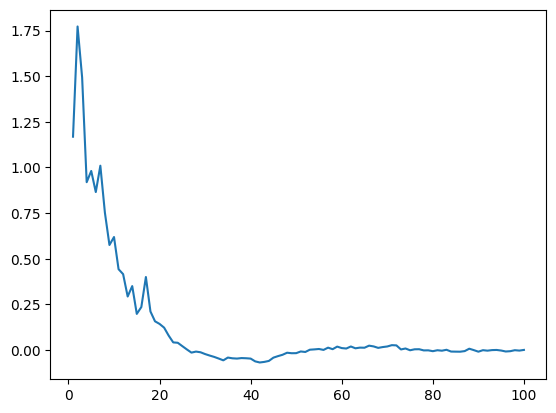

In [ ]:
# Uncomment once train_vmc_baseline is implemented:
model_trained, losses  = train_vmc_baseline(L=L, g2=2.0, n_iters=100, batch=32, lr=5e-2)

import matplotlib.pyplot as plt
# PLot the loss curve and acceptance rate curve over iterations to check training progress.
plt.plot(np.arange(1, 101), losses)

### 10.1 TODO: complex activation cELU

## 10. (Capstone) Build the Equ-NN architecture

At this point you have:
- periodic lattice + plaquettes
- gauge transformations
- MH sampling
- FD local energy
- a baseline gauge-invariant \(\log\psi\)

Now you can implement the Equ-NN model in stages:
1. `cELU`
2. `ComplexConv2d`
3. `ComplexCNN`
4. `EquivariantBlock`
5. `InvariantHead`
6. `EquNN_U1`

Below are scaffolds for the first two building blocks.


In [ ]:
class cELU(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, z):
        """
        z: complex tensor
        return ELU(Re z) + i ELU(Im z)
        """
        # TODO: implement using F.elu on real and imag parts

        import torch.nn.functional as F
        real_part = F.elu(z.real, alpha=self.alpha)
        imag_part = F.elu(z.imag, alpha=self.alpha)
        return torch.complex(real_part, imag_part)

### 10.2 TODO: complex convolution via two real convolutions

In [ ]:
class ComplexConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, bias=True):
        super().__init__()
        self.ks = int(kernel_size)
        self.pad = self.ks // 2

        # Real conv weights (no bias); we will add a single complex bias ourselves.
        self.Wr = nn.Conv2d(in_ch, out_ch, self.ks, padding=0, bias=False)
        self.Wi = nn.Conv2d(in_ch, out_ch, self.ks, padding=0, bias=False)

        if bias:
            self.br = nn.Parameter(torch.zeros(out_ch, device=device, dtype=dtype))
            self.bi = nn.Parameter(torch.zeros(out_ch, device=device, dtype=dtype))
        else:
            self.br = None
            self.bi = None

    def forward(self, z):
        """
        z: (B, in_ch, H, W) complex
        returns: (B, out_ch, H, W) complex
        """
        xr, xi = z.real, z.imag

        # TODO: implement circular padding if self.pad>0
        if self.pad > 0:
            xr = torch.nn.functional.pad(xr, (self.pad, self.pad, self.pad, self.pad), mode='circular')
            xi = torch.nn.functional.pad(xi, (self.pad, self.pad, self.pad, self.pad), mode='circular')

        # TODO: implement complex convolution:
        # (Wr + iWi)(xr + ixi) = (Wr*xr - Wi*xi) + i(Wr*xi + Wi*xr)
        yr = self.Wr(xr) - self.Wi(xi)
        yi = self.Wr(xi) + self.Wi(xr)

        if self.br is not None and self.bi is not None:
            yr += self.br.view(1, -1, 1, 1)
            yi += self.bi.view(1, -1, 1, 1)

        return torch.complex(yr, yi)

### 10.3 Quick unit test for ComplexConv2d (should pass after TODOs)

In [ ]:
# Uncomment after implementing ComplexConv2d:
Btest, Cin, Cout, H, W = 2, 3, 5, 4, 4
z = torch.randn(Btest, Cin, H, W, device=device, dtype=dtype) + 1j*torch.randn(Btest, Cin, H, W, device=device, dtype=dtype)
layer = ComplexConv2d(Cin, Cout, kernel_size=3).to(device=device, dtype=dtype)
y = layer(z)
print("y.shape:", y.shape)
assert y.shape == (Btest, Cout, H, W)


y.shape: torch.Size([2, 5, 4, 4])


## 11. Next steps (after TODOs)

1. Replace the baseline with your full `EquNN_U1` model.
2. Reuse the same sampler and local energy estimator.
3. Scan \(g^2\) values and plot \(E_0(g^2)\).

If you want, after you finish the TODOs, I can add:
- a collapsed “solutions” appendix,
- automated grading-style checks,
- or speed/stability improvements for larger \(L\).


In [ ]:
# ============================================================
# HW 1) Implement ComplexCNN
# Goal: build a small complex CNN stack from ComplexConv2d + cELU
# ============================================================

class ComplexCNN(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, kernel_size, n_layers=2):
        super().__init__()
        assert n_layers >= 1

        # TODO:
        # 1) Build a list `layers` such that:
        #    (ComplexConv2d -> cELU) repeated (n_layers-1) times
        #    then final ComplexConv2d to out_ch
        # 2) Wrap in nn.Sequential
        layers = []
        ch = in_ch
        for _ in range(n_layers - 1):
            layers += [ComplexConv2d(ch, hidden_ch, kernel_size), cELU()]
            ch = hidden_ch
        layers += [ComplexConv2d(ch, out_ch, kernel_size)]
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        # TODO: just forward through self.net
        return self.net(z)

# ---- sanity check ----
B, H, W = 4, 5, 6
z = torch.randn(B, 3, H, W, device=device, dtype=dtype) + 1j*torch.randn(B, 3, H, W, device=device, dtype=dtype)
cnn = ComplexCNN(in_ch=3, hidden_ch=8, out_ch=5, kernel_size=3, n_layers=2).to(device=device, dtype=dtype)
out = cnn(z)
print("ComplexCNN out shape:", out.shape)
assert out.shape == (B, 5, H, W)
assert torch.isfinite(out.real).all() and torch.isfinite(out.imag).all()
print("HW1 passed.")

ComplexCNN out shape: torch.Size([4, 5, 5, 6])
HW1 passed.


In [ ]:
# ============================================================
# HW 2) Implement EquivariantBlock
# Goal: take link-like features E (B,F,2,H,W), build plaquette loops P (B,F,H,W),
# run CNN on P to produce modulation M (B,F,2,H,W), then update E.
# ============================================================

class EquivariantBlock(nn.Module):
    def __init__(self, Ffeat, kernel_size=3, cnn_layers=2, hidden=None):
        super().__init__()
        hidden = hidden or Ffeat
        self.cnn = ComplexCNN(in_ch=Ffeat, hidden_ch=hidden, out_ch=2*Ffeat,
                              kernel_size=kernel_size, n_layers=cnn_layers)
        self.act = cELU()

    def forward(self, E):
        # E: (B,F,2,H,W) complex
        # TODO 1: split Ex, Ey
        Ex = E[:, :, 0]  # (B,F,H,W)
        Ey = E[:, :, 1]  # (B,F,H,W)

        # TODO 2: compute per-feature plaquette loop P = Ex * Ey(x+1) * Ex(y+1)^* * Ey^*
        P = Ex * shift_x_fwd(Ey) * torch.conj(shift_y_fwd(Ex)) * torch.conj(Ey)  # (B,F,H,W)

        # TODO 3: apply CNN to P to get M of shape (B,2F,H,W), then reshape to (B,F,2,H,W)
        M = self.cnn(P)  # (B,2F,H,W)
        B, _, H, W = M.shape
        Ffeat = E.shape[1]
        M = M.view(B, Ffeat, 2, H, W)

        # TODO 4: return equivariant update with residual: E + E * cELU(M)
        return E + E * self.act(M)

# ---- sanity check ----
B, Ffeat, H, W = 2, 3, 4, 4
E = torch.randn(B, Ffeat, 2, H, W, device=device, dtype=dtype) + 1j*torch.randn(B, Ffeat, 2, H, W, device=device, dtype=dtype)
blk = EquivariantBlock(Ffeat=Ffeat, kernel_size=3, cnn_layers=2).to(device=device, dtype=dtype)
E2 = blk(E)
print("EquivariantBlock out shape:", E2.shape)
assert E2.shape == E.shape
assert torch.isfinite(E2.real).all() and torch.isfinite(E2.imag).all()
print("HW2 passed.")


EquivariantBlock out shape: torch.Size([2, 3, 2, 4, 4])
HW2 passed.


In [ ]:
# ============================================================
# HW 3) Implement InvariantHead
# Goal: map E -> plaquette loops P -> ComplexCNN -> spatial mean -> real logpsi
# ============================================================

class InvariantHead(nn.Module):
    def __init__(self, Ffeat, inv_features=4, kernel_size=3, inv_layers=2):
        super().__init__()
        self.cnn = ComplexCNN(in_ch=Ffeat, hidden_ch=inv_features, out_ch=inv_features,
                              kernel_size=kernel_size, n_layers=inv_layers)
        self.lin = nn.Linear(2*inv_features, 1)

    def forward(self, E):
        # TODO 1: build plaquette loops P from E (same as in EquivariantBlock)
        Ex = E[:, :, 0]
        Ey = E[:, :, 1]
        P = Ex * shift_x_fwd(Ey) * torch.conj(shift_y_fwd(Ex)) * torch.conj(Ey)  # (B,F,H,W)

        # TODO 2: run CNN, average pool over space
        Z = self.cnn(P)                 # (B,inv_features,H,W) complex
        zbar = Z.mean(dim=(-2, -1))     # (B,inv_features) complex

        # TODO 3: concat real and imag -> linear -> (B,)
        feat = torch.cat([zbar.real, zbar.imag], dim=-1)  # (B,2*inv_features)
        logpsi = self.lin(feat).squeeze(-1)
        return logpsi

# ---- sanity check ----
B, Ffeat, H, W = 5, 2, 4, 4
E = torch.randn(B, Ffeat, 2, H, W, device=device, dtype=dtype) + 1j*torch.randn(B, Ffeat, 2, H, W, device=device, dtype=dtype)
head = InvariantHead(Ffeat=Ffeat, inv_features=4, kernel_size=3, inv_layers=2).to(device=device, dtype=dtype)
logpsi = head(E)
print("InvariantHead out shape:", logpsi.shape)
assert logpsi.shape == (B,)
assert torch.isfinite(logpsi).all()
print("HW3 passed.")


InvariantHead out shape: torch.Size([5])
HW3 passed.


In [ ]:
# ============================================================
# HW 4) Implement EquNN_U1
# Goal: theta -> U = exp(i theta) -> direction-preserving lift -> eq blocks -> invariant head
# IMPORTANT: do NOT mix x- and y-links in the lift, or gauge covariance breaks.
# ============================================================

class EquNN_U1(nn.Module):
    def __init__(self, L, eq_layers=2, eq_features=2,
                 kernel_size=3, eq_cnn_layers=2,
                 inv_features=4, inv_layers=2):
        super().__init__()
        self.L = int(L)
        self.eq_features = int(eq_features)

        # TODO 1: direction-preserving lift
        self.lift_x = ComplexConv2d(in_ch=1, out_ch=self.eq_features, kernel_size=1, bias=True)
        self.lift_y = ComplexConv2d(in_ch=1, out_ch=self.eq_features, kernel_size=1, bias=True)

        # TODO 2: equivariant blocks
        self.eq_blocks = nn.ModuleList([
            EquivariantBlock(self.eq_features, kernel_size=kernel_size, cnn_layers=eq_cnn_layers)
            for _ in range(eq_layers)
        ])

        # TODO 3: invariant head
        self.head = InvariantHead(self.eq_features, inv_features=inv_features,
                                  kernel_size=kernel_size, inv_layers=inv_layers)

    def forward(self, theta):
        # theta: (B,2,L,L) real
        U = link_phases(theta)         # (B,2,L,L) complex
        Ux = U[:, 0:1]                 # (B,1,L,L)
        Uy = U[:, 1:2]                 # (B,1,L,L)

        # lift separately
        Ex = self.lift_x(Ux)           # (B,F,L,L)
        Ey = self.lift_y(Uy)           # (B,F,L,L)

        # pack as link-like features
        E = torch.stack([Ex, Ey], dim=2)  # (B,F,2,L,L)

        for blk in self.eq_blocks:
            E = blk(E)

        return self.head(E)            # (B,) real logpsi

# ---- sanity check ----
B, L = 8, 2
theta = (TWOPI * torch.rand(B, 2, L, L, device=device, dtype=dtype)) % TWOPI
model = EquNN_U1(L=L).to(device=device, dtype=dtype)
out = model(theta)
print("EquNN_U1 out shape:", out.shape)
assert out.shape == (B,)
assert torch.isfinite(out).all()
print("HW4 passed.")


EquNN_U1 out shape: torch.Size([8])
HW4 passed.


In [ ]:
# ============================================================
# HW 5) Gauge-invariance sanity check
# Goal: verify logpsi(theta) == logpsi(g·theta) up to numerical precision.
# If this fails, do NOT sweep yet.
# ============================================================

@torch.no_grad()
def gauge_invariance_sanity(model, theta, ntests=5):
    errs = []
    for _ in range(ntests):
        alpha = (TWOPI * torch.rand(theta.shape[0], theta.shape[2], theta.shape[3],
                                    device=theta.device, dtype=theta.dtype)) % TWOPI
        th2 = apply_gauge_transform(theta, alpha)
        errs.append((model(theta) - model(th2)).abs().max().item())
    return max(errs)

B, L = 16, 2
theta = (TWOPI * torch.rand(B, 2, L, L, device=device, dtype=dtype)) % TWOPI
model = EquNN_U1(L=L).to(device=device, dtype=dtype)

err = gauge_invariance_sanity(model, theta, ntests=3)
print("max |logpsi(theta) - logpsi(g·theta)| =", err)

# Expect tiny (numerical) error if your architecture is truly gauge invariant
assert err < 1e-7
print("HW5 passed: gauge invariance sanity check.")


max |logpsi(theta) - logpsi(g·theta)| = 8.604228440844963e-16
HW5 passed: gauge invariance sanity check.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming TWOPI, device, dtype, and EquNN_U1 are defined elsewhere in the notebook
# (e.g., in cells 0. Setup and 10. Capstone)

# ============================================================
# Sweep cell: Train EquNN at each g^2 and plot energy
# ============================================================

def train_vmc_equnn(
    L=2, g2=1.0, mag_prefactor=1.0,
    n_iters=200, batch=32,
    burn_sweeps=30, between_sweeps=5,
    mh_step_size=0.25, lr=2e-3,
    eps_fd=1e-2, chunk_links=8, seed=0
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = EquNN_U1(L=L).to(device=device, dtype=dtype)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    theta = (TWOPI * torch.rand(batch, 2, L, L, device=device, dtype=dtype)) % TWOPI
    losses = []

    # burn-in
    theta, acc = mh_sample(model, theta, n_sweeps=burn_sweeps, step_size=mh_step_size)

    for it in range(n_iters):
        theta, acc = mh_sample(model, theta, n_sweeps=between_sweeps, step_size=mh_step_size)

        with torch.no_grad():
            E_loc = local_energy_fd(theta, model, g2=g2, mag_prefactor=mag_prefactor,
                                    eps=eps_fd, chunk_links=chunk_links)
            E_mean = E_loc.mean()

        logpsi = model(theta)  # grads flow here
        loss = 2.0 * torch.mean((E_loc - E_mean) * logpsi)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.detach().item())
        if it % 50 == 0 or it == n_iters - 1:
            print(f"g^2={g2:.1f}  it={it:4d}  <E>={float(E_mean): .6f}  acc={acc:.3f}")


    plt.plot(range(n_iters),losses)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title(f'Loss vs Iterations for g^2={g2}')
    plt.show()

    return model


@torch.no_grad()
def estimate_energy(
    model, L, g2, mag_prefactor=1.0,
    batch=256, burn_sweeps=80, meas_sweeps=40,
    mh_step_size=0.25, eps_fd=1e-2, chunk_links=8
):
    theta = (TWOPI * torch.rand(batch, 2, L, L, device=device, dtype=dtype)) % TWOPI
    theta, _ = mh_sample(model, theta, n_sweeps=burn_sweeps, step_size=mh_step_size)
    theta, acc = mh_sample(model, theta, n_sweeps=meas_sweeps, step_size=mh_step_size)

    E_loc = local_energy_fd(theta, model, g2=g2, mag_prefactor=mag_prefactor,
                            eps=eps_fd, chunk_links=chunk_links)

    mean = float(E_loc.mean().item())
    std  = float(E_loc.std().item())
    sem  = std / np.sqrt(batch)
    return mean, sem, acc, theta

# magnetic and kinetic energy

@torch.no_grad()
def estimate_mag_energy(
    model, theta, L, g2, mag_prefactor=1.0,
    batch=256 # batch size is already determined by theta
):
    # theta is already sampled from estimate_energy
    psi = torch.exp(model(theta))
    E_mag = magnetic_energy(theta, g2=g2, mag_prefactor=mag_prefactor)
    # mag_expect = E_mag * torch.abs(psi)**2
    mag_expect = E_mag

    mean = float(mag_expect.mean().item())
    std = float(mag_expect.std().item())
    sem  = std / np.sqrt(batch)

    return mean, sem


@torch.no_grad()
def estimate_kin_energy(
    model, theta, L, g2, mag_prefactor=1.0,
    eps=1e-2, # eps_fd is used in local_energy_fd, this eps for FD of kinetic part
    batch=256 # batch size is already determined by theta
):
    # theta is already sampled from estimate_energy
    logpsi0 = model(theta)
    Ekin_total = torch.zeros(batch, device=device, dtype=dtype)
    clamp_dlog = 30.0 # Define this for consistency

    for mu in range(2):
        for y in range(L):
            for x in range(L):
                theta_plus = theta.clone()
                theta_minus = theta.clone()

                theta_plus[:, mu, y, x] = (theta_plus[:, mu, y, x] + eps) % TWOPI
                theta_minus[:, mu, y, x] = (theta_minus[:, mu, y, x] - eps) % TWOPI

                logpsi_plus = model(theta_plus)
                logpsi_minus = model(theta_minus)

                dlog_plus = torch.clamp(logpsi_plus - logpsi0, max=clamp_dlog, min=-clamp_dlog)
                dlog_minus = torch.clamp(logpsi_minus - logpsi0, max=clamp_dlog, min=-clamp_dlog)

                Ekin_link_contrib = -(torch.exp(dlog_plus) + torch.exp(dlog_minus) - 2) / (eps * eps)
                Ekin_total += Ekin_link_contrib

    mean = float((g2/2 * Ekin_total).mean().item())
    std = float((g2/2 * Ekin_total).std().item())
    sem  = std / np.sqrt(batch)

    return mean, sem



=== Train EquNN for g^2=1.0 ===
g^2=1.0  it=   0  <E>= 4.328328  acc=0.995
g^2=1.0  it=  50  <E>= 2.925129  acc=0.958
g^2=1.0  it= 100  <E>= 2.906240  acc=0.949
g^2=1.0  it= 150  <E>= 2.953938  acc=0.933
g^2=1.0  it= 199  <E>= 2.903615  acc=0.947


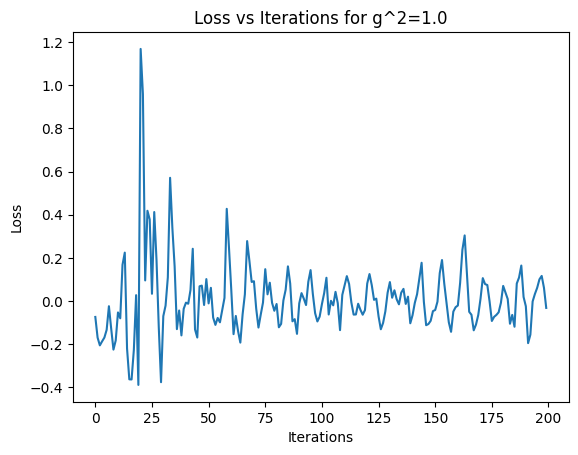

[estimate] g^2=1.0  E/plaquette=0.730314 ± 0.002408  acc=0.948

=== Train EquNN for g^2=2.0 ===
g^2=2.0  it=   0  <E>= 2.164975  acc=0.995
g^2=2.0  it=  50  <E>= 1.880441  acc=0.992
g^2=2.0  it= 100  <E>= 1.859790  acc=0.991
g^2=2.0  it= 150  <E>= 1.875523  acc=0.987
g^2=2.0  it= 199  <E>= 1.868141  acc=0.982


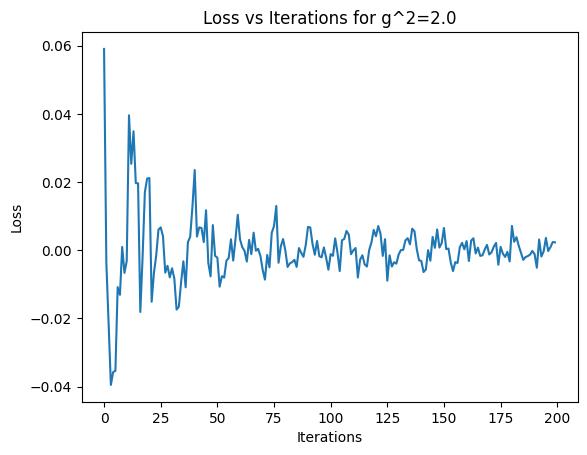

[estimate] g^2=2.0  E/plaquette=0.469158 ± 0.000515  acc=0.987

=== Train EquNN for g^2=3.0 ===
g^2=3.0  it=   0  <E>= 1.444218  acc=0.995
g^2=3.0  it=  50  <E>= 1.277364  acc=0.996
g^2=3.0  it= 100  <E>= 1.297366  acc=0.996
g^2=3.0  it= 150  <E>= 1.305685  acc=0.992
g^2=3.0  it= 199  <E>= 1.301289  acc=0.998


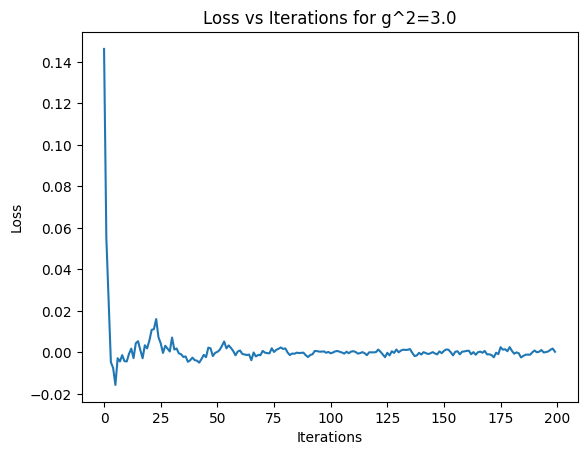

[estimate] g^2=3.0  E/plaquette=0.324194 ± 0.000388  acc=0.994

=== Train EquNN for g^2=4.0 ===
g^2=4.0  it=   0  <E>= 1.084110  acc=0.995
g^2=4.0  it=  50  <E>= 0.972109  acc=0.999
g^2=4.0  it= 100  <E>= 0.986960  acc=0.998
g^2=4.0  it= 150  <E>= 0.987622  acc=0.996
g^2=4.0  it= 199  <E>= 0.990017  acc=0.999


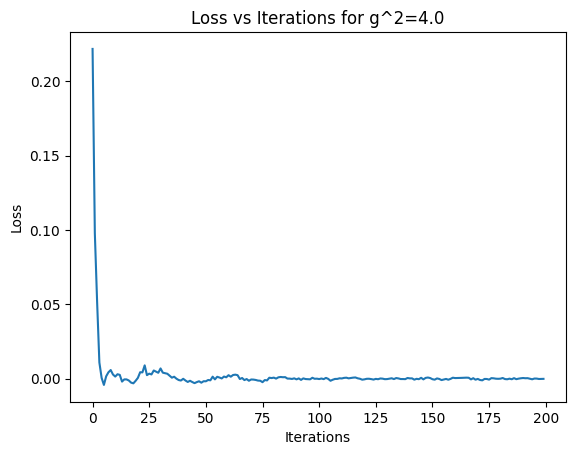

[estimate] g^2=4.0  E/plaquette=0.245852 ± 0.000410  acc=0.997


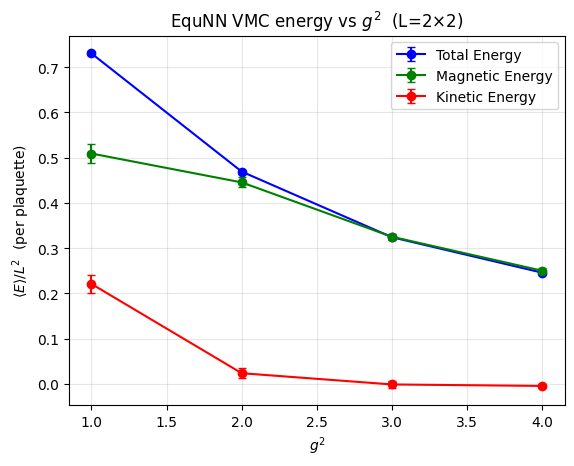

In [ ]:
# ---- run sweep ----
# # To save the model
# from google.colab import drive
# drive.mount('/content/drive')

L = 2
g2_list = [1.0, 2.0, 3.0, 4.0]

file_paths = ['/content/drive/MyDrive/model_state_dict_g21.pth',
              '/content/drive/MyDrive/model_state_dict_g22.pth',
              '/content/drive/MyDrive/model_state_dict_g23.pth',
              '/content/drive/MyDrive/model_state_dict_g24.pth']

Epp_means = []
Epp_sems  = []
accs      = []

Emag_means = []
Emag_sems = []

Ekin_means = []
Ekin_sems = []

wave_fns = []
p_angles = []


for g2 in g2_list:
    print(f"\n=== Train EquNN for g^2={g2} ===")
    trained_model = train_vmc_equnn(L=L, g2=g2, n_iters=200, batch=32, lr=2e-3,
                            burn_sweeps=30, between_sweeps=5,
                            mh_step_size=0.25, eps_fd=1e-2, chunk_links=8, seed=0)

    # # Save the state dictionary to Google Drive
    # torch.save(trained_model.state_dict(), file_paths[int(g2)-1]) # Changed 'model' to 'trained_model'

    # energy eigenvalue
    meanE, semE, acc, measured_theta = estimate_energy(trained_model, L=L, g2=g2, batch=256,
                                       burn_sweeps=80, meas_sweeps=40,
                                       mh_step_size=0.25, eps_fd=1e-2, chunk_links=8)

    # per plaquette (L^2 plaquettes) for readability
    Epp_means.append(meanE/(L*L))
    Epp_sems.append(semE/(L*L))
    accs.append(acc)


    # add magnetic / kinetic energy
    # Pass the 'measured_theta' obtained from estimate_energy to ensure consistency
    mean_mag_E, sem_mag_E = estimate_mag_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)
    mean_kin_E, sem_kin_E = estimate_kin_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)

    Emag_means.append(mean_mag_E/(L*L))
    Emag_sems.append(sem_mag_E/(L*L))

    Ekin_means.append(mean_kin_E/(L*L))
    Ekin_sems.append(sem_kin_E/(L*L))

    # store (plaquette value, wave function) for each g2
    p_angle = plaquette_angle(measured_theta)[:,0,0]
    wave_fns.append([p_angle, trained_model(measured_theta)])
    p_angles.append(plaquette_angle(measured_theta))

    print(f"[estimate] g^2={g2}  E/plaquette={Epp_means[-1]:.6f} \u00b1 {Epp_sems[-1]:.6f}  acc={acc:.3f}")



# Plot kinetic and magnetic energy separately
# ---- plot energy ----
plt.figure()
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.errorbar(g2_list, Emag_means, yerr=Emag_sems, fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
plt.errorbar(g2_list, Ekin_means, yerr=Ekin_sems, fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comment:

Used mathieum function from scipy library: https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.mathieu_cem.html#scipy.special.mathieu_cem

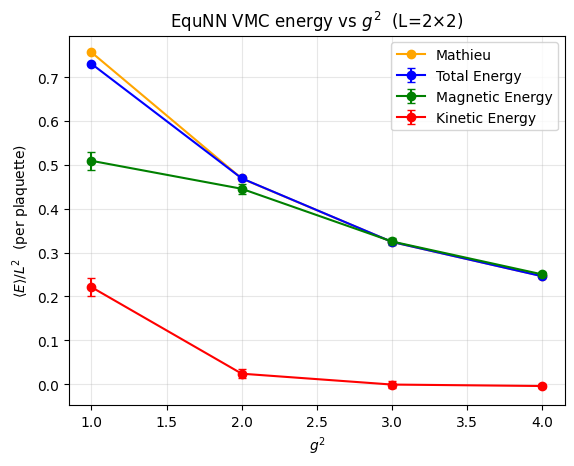

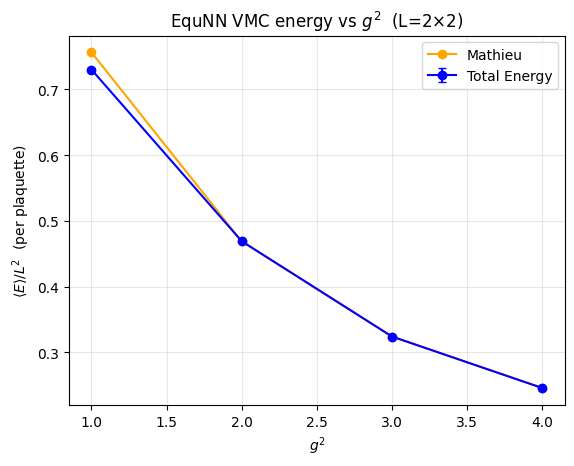

In [ ]:
from scipy.special import mathieu_a

mathieu_energy = []

g2_list = [1.0, 2.0, 3.0, 4.0]
g = np.linspace(1.0, 2.0, 100)

for g2 in g2_list:
  mathieu_energy.append(2*g2 * mathieu_a(0, -1.0/(2.0*g2**2)) + 1.0/g2)



# Plot kinetic and magnetic energy separately
# ---- plot energy ----
plt.figure()
# plt.plot(g**2, y, label=r"Analytical GS energy $E_0(g^2)$")
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.errorbar(g2_list, Emag_means, yerr=Emag_sems, fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
plt.errorbar(g2_list, Ekin_means, yerr=Ekin_sems, fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
plt.plot(g2_list, mathieu_energy, 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Only compare total energy
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.plot(g2_list, mathieu_energy, 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

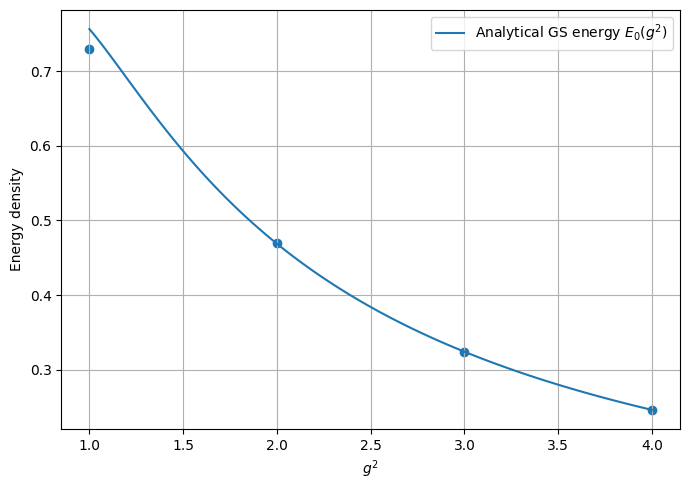

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import mathieu_a
def q_of_g(g):
    return -1.0/(2.0*g**4)

def En(g):
    return 2*g**2 * mathieu_a(0, q_of_g(g)) + 1.0/g**2

g2_list = [1.0, 2.0, 3.0, 4.0]
E_dat = [0.730314, 0.469158, 0.324194, 0.245852]
g = np.linspace(1.0, 2.0, 100)
y = np.array([En(gi) for gi in g])

plt.figure(figsize=(7,5))
plt.scatter(g2_list, E_dat)
plt.plot(g**2, y, label=r"Analytical GS energy $E_0(g^2)$")
plt.xlabel(r"$g^2$")
plt.ylabel("Energy density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# One plaquette experiment

Tried one plaquette experiment: doesn't seem to work...
So I just took the lower left plaquette value out of four-plaqutte lattice.  (It turns out that the four plaqutte values are all different.)

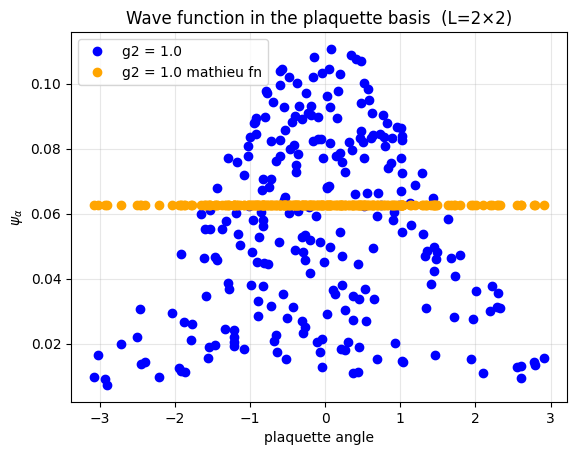

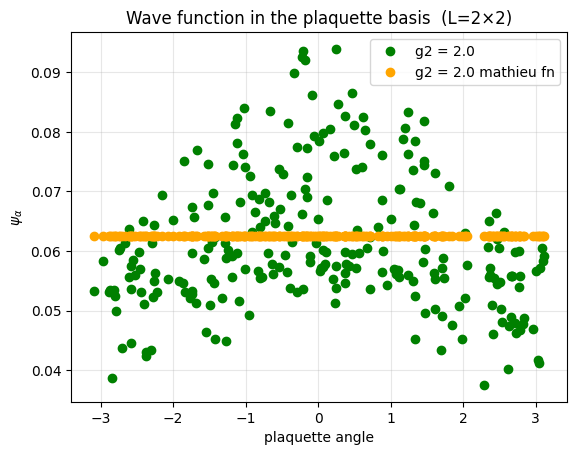

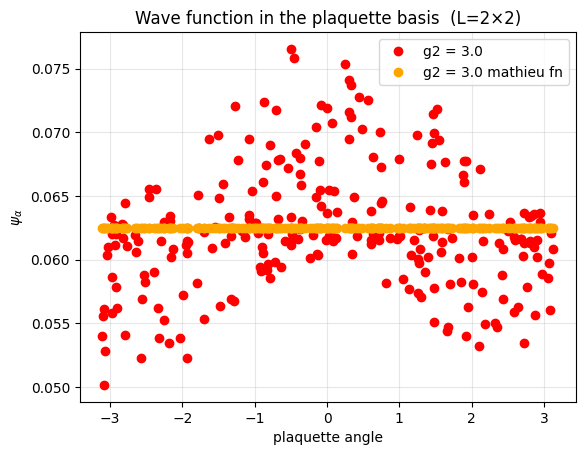

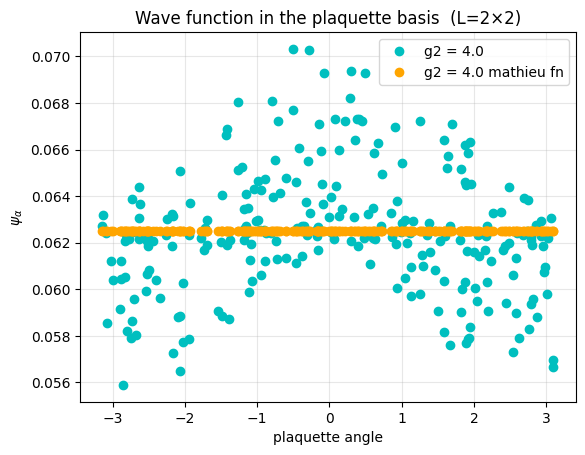

In [ ]:
import scipy
# ---- plot wave function vs plaquette angle ----
plt.figure()

for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    # p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    p_angle = ((p_angles[i][:,1,0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    psi = torch.exp(wave_fns[i][1])
    normalisation = torch.sqrt(torch.sum(psi **2))
    normalised_wf = psi / normalisation

    y_plot = normalised_wf.detach().cpu().numpy()
    mathieu, _ = scipy.special.mathieu_cem(0, -1/(2* g2**2), x_plot/2)
    normalised_mathieu = mathieu / np.sqrt(np.sum(mathieu **2))

    # mathieu_energy.append(2*g2 * mathieu_a(0, -1.0/(2.0*g2**2)) + 1.0/g2)

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, y_plot, 'o', color=colors[i], label=f'g2 = {g2_val}')
    plt.plot(x_plot, normalised_mathieu, 'o', color='orange', label=f'g2 = {g2_val} mathieu fn')
    plt.xlabel(r"plaquette angle")
    plt.ylabel(r"$\psi_\alpha $")
    plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
torch.sum(p_angles[0], dim=(1,2)).shape

In [ ]:
# # ---- plot wave function vs averaged plaquette angle ----
# plt.figure()

# for i, g2_val in enumerate(g2_list):
#     # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
#     avg_p_angle = torch.sum(p_angles[i],dim=(1,2))
#     p_angle = ((avg_p_angle + TWOPI/2) % TWOPI ) - TWOPI/2
#     x_plot = p_angle.flatten().detach().cpu().numpy()

#     psi = torch.exp(wave_fns[i][1])
#     normalisation = torch.sqrt(torch.sum(psi **2))
#     normalised_wf = psi / normalisation

#     y_plot = normalised_wf.detach().cpu().numpy()
#     mathieu, _ = scipy.special.mathieu_cem(0, -1/(2* g2**2), x_plot/2)
#     normalised_mathieu = mathieu / np.sqrt(np.sum(mathieu **2))

#     # mathieu_energy.append(2*g2 * mathieu_a(0, -1.0/(2.0*g2**2)) + 1.0/g2)

#     # Use different colors for each g2 value
#     colors = ['b', 'g', 'r', 'c']
#     plt.plot(x_plot, y_plot, 'o', color=colors[i], label=f'g2 = {g2_val}')
#     plt.plot(x_plot, normalised_mathieu, 'o', color='orange', label=f'g2 = {g2_val} mathieu fn')
#     plt.xlabel(r"plaquette angle")
#     plt.ylabel(r"$\psi_\alpha $")
#     plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

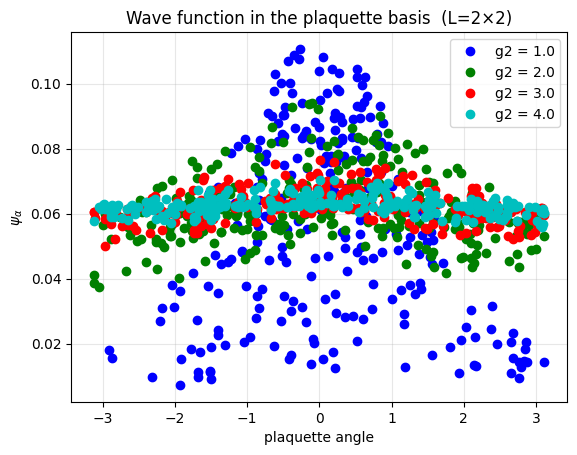

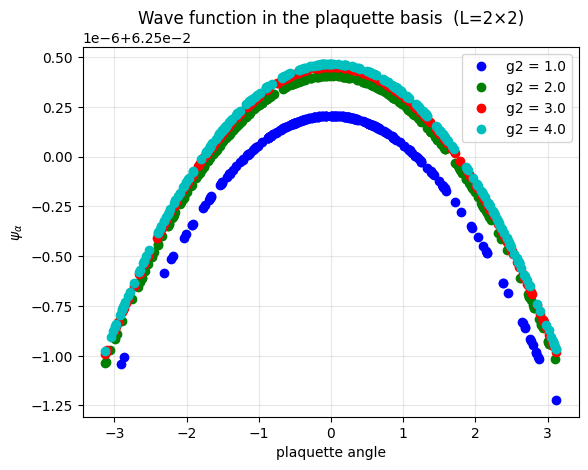

In [ ]:
# ---- plot wave function vs plaquette angle ----
plt.figure()

for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    # y_plot = normalised_mathieu
    psi = torch.exp(wave_fns[i][1])
    normalisation = torch.sqrt(torch.sum(psi **2))
    normalised_wf = psi / normalisation
    y_plot = normalised_wf.detach().cpu().numpy()

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, y_plot, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Plot the matthieu function
for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    mathieu, _ = scipy.special.mathieu_cem(0, -1/(2* g2**2), x_plot/2)
    normalised_mathieu = mathieu / np.sqrt(np.sum(mathieu **2))

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, normalised_mathieu, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[0.99614372 0.99705727 0.99774324 0.99820093 0.99842989 0.99842989
 0.99820093 0.99774324 0.99705727 0.99614372]


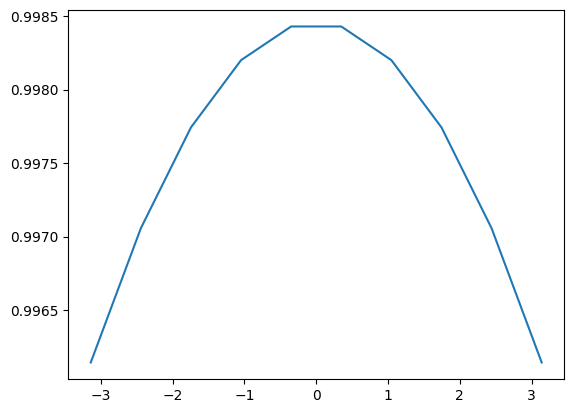

In [ ]:
import scipy
xrange = np.linspace(-TWOPI/2,TWOPI/2,10)
mathieu, _ = scipy.special.mathieu_cem(0, -16/(g2**2), xrange)
print(mathieu)
plt.plot(xrange,mathieu)

# Saving/loading the model

Tried to save/load the state dict of the model but the loaded model didn't look like the full model above.  Maybe one has to save the entire model, instead of the state dict.

In [ ]:
# ######### Effort to load the saved state dict didn't work :/

# Epp_means = []
# Epp_sems  = []
# accs      = []

# Emag_means = []
# Emag_sems = []

# Ekin_means = []
# Ekin_sems = []

# wave_fns = []

# for g2 in g2_list:
#     print(f"\n=== Train EquNN for g^2={g2} ===")
#     trained_model = train_vmc_equnn(L=L, g2=g2, n_iters=0, batch=256, lr=2e-3,
#                             burn_sweeps=0, between_sweeps=5,
#                             mh_step_size=0.25, eps_fd=1e-2, chunk_links=8, seed=0)
#     trained_model.load_state_dict(torch.load(file_paths[int(g2)-1]))
#     trained_model.eval()

#     # energy eigenvalue
#     meanE, semE, acc, measured_theta = estimate_energy(trained_model, L=L, g2=g2, batch=256,
#                                        burn_sweeps=80, meas_sweeps=40,
#                                        mh_step_size=0.25, eps_fd=1e-2, chunk_links=8)

#     # per plaquette (L^2 plaquettes) for readability
#     Epp_means.append(meanE/(L*L))
#     Epp_sems.append(semE/(L*L))
#     accs.append(acc)


#     # add magnetic / kinetic energy
#     # Pass the 'measured_theta' obtained from estimate_energy to ensure consistency
#     mean_mag_E, sem_mag_E = estimate_mag_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)
#     mean_kin_E, sem_kin_E = estimate_kin_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)

#     Emag_means.append(mean_mag_E/(L*L))
#     Emag_sems.append(sem_mag_E/(L*L))

#     Ekin_means.append(mean_kin_E/(L*L))
#     Ekin_sems.append(sem_kin_E/(L*L))

#     # store (plaquette value, wave function) for each g2
#     wave_fns.append([plaquette_angle(measured_theta), trained_model(measured_theta)])

#     print(f"[estimate] g^2={g2}  E/plaquette={Epp_means[-1]:.6f} \u00b1 {Epp_sems[-1]:.6f}  acc={acc:.3f}")

# # Plot kinetic and magnetic energy separately
# # ---- plot energy ----
# plt.figure()
# plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
# plt.errorbar(g2_list, Emag_means, yerr=Emag_sems, fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
# plt.errorbar(g2_list, Ekin_means, yerr=Ekin_sems, fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
# plt.xlabel(r"$g^2$")
# plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
# plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()



In [ ]:
# # To save the model
# from google.colab import drive
# drive.mount('/content/drive')

# # Save the state dictionary to Google Drive
# torch.save(model.state_dict(), '/content/drive/MyDrive/model_state_dict_g24.pth')

# # # To load the model
# # model2 = train_vmc_equnn(L=L, g2=g2, n_iters=200, batch=32, lr=2e-3,
# #                             burn_sweeps=30, between_sweeps=5,
# #                             mh_step_size=0.25, eps_fd=1e-2, chunk_links=8, seed=0)
# # model2.load_state_dict(torch.load('model_state_dict.pth'))
# # model2.eval()


=== Train EquNN for g^2=1.0 ===
g^2=1.0  it=   0  <E>= 65.460242  acc=0.999
g^2=1.0  it=  50  <E>= 55.766637  acc=0.961
g^2=1.0  it= 100  <E>=-6156411215948818432.000000  acc=0.162
g^2=1.0  it= 150  <E>=-1078175585497041152.000000  acc=0.134
g^2=1.0  it= 199  <E>=-1465291098749515776.000000  acc=0.216


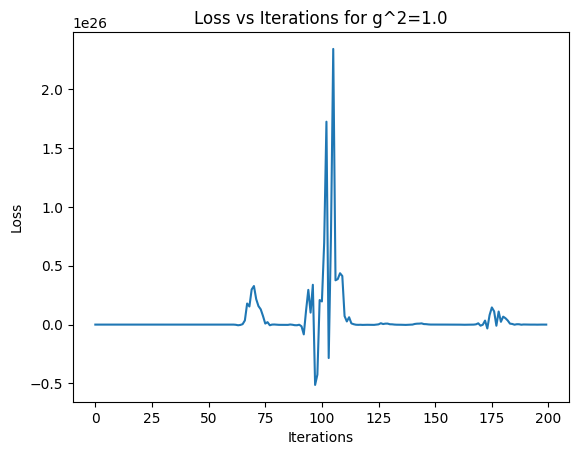

[estimate] g^2=1.0  E/plaquette=-4742203557170174.000000 ± 210681519854377.125000  acc=0.103

=== Train EquNN for g^2=2.0 ===
g^2=2.0  it=   0  <E>= 32.732828  acc=0.999
g^2=2.0  it=  50  <E>= 30.119725  acc=0.989
g^2=2.0  it= 100  <E>= 30.220802  acc=0.987
g^2=2.0  it= 150  <E>= 30.016839  acc=0.988
g^2=2.0  it= 199  <E>= 29.959277  acc=0.988


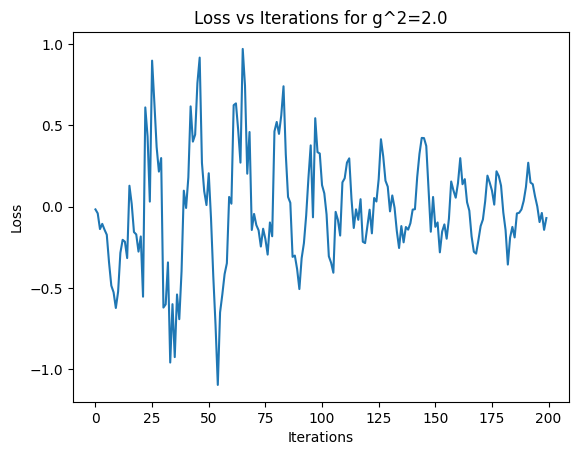

[estimate] g^2=2.0  E/plaquette=0.468973 ± 0.000261  acc=0.988

=== Train EquNN for g^2=3.0 ===
g^2=3.0  it=   0  <E>= 21.824893  acc=0.999
g^2=3.0  it=  50  <E>= 20.863868  acc=0.995
g^2=3.0  it= 100  <E>= 20.751606  acc=0.994
g^2=3.0  it= 150  <E>= 20.807129  acc=0.994
g^2=3.0  it= 199  <E>= 20.728005  acc=0.994


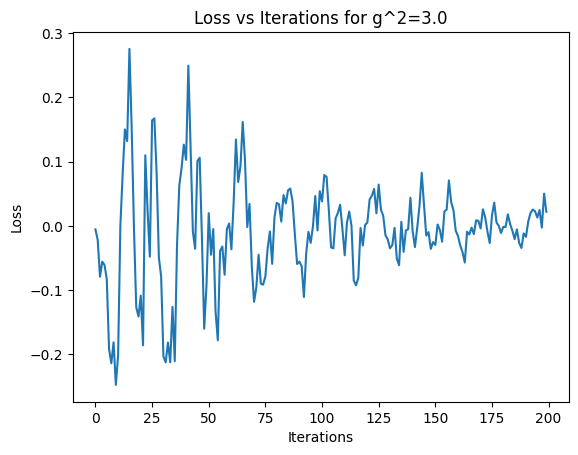

[estimate] g^2=3.0  E/plaquette=0.324005 ± 0.000165  acc=0.995

=== Train EquNN for g^2=4.0 ===
g^2=4.0  it=   0  <E>= 16.371828  acc=0.999
g^2=4.0  it=  50  <E>= 15.818816  acc=0.997
g^2=4.0  it= 100  <E>= 15.781623  acc=0.997
g^2=4.0  it= 150  <E>= 15.744404  acc=0.996
g^2=4.0  it= 199  <E>= 15.757067  acc=0.997


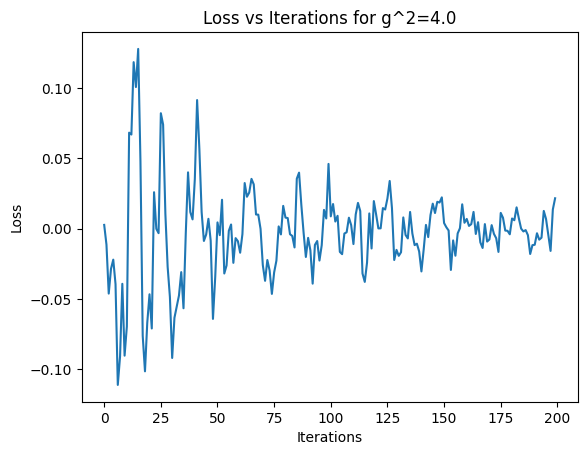

[estimate] g^2=4.0  E/plaquette=0.245882 ± 0.000139  acc=0.997


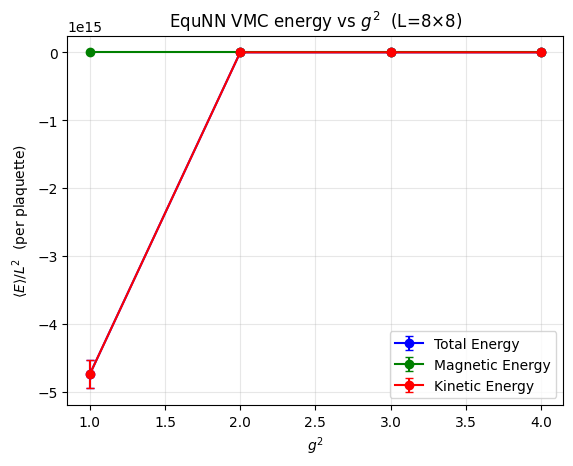

In [ ]:
# Applying to more sites L = 8

L = 8
g2_list = [1.0, 2.0, 3.0, 4.0]

Epp_means = []
Epp_sems  = []
accs      = []

Emag_means = []
Emag_sems = []

Ekin_means = []
Ekin_sems = []

wave_fns = []
p_angles = []


for g2 in g2_list:
    print(f"\n=== Train EquNN for g^2={g2} ===")
    trained_model = train_vmc_equnn(L=L, g2=g2, n_iters=200, batch=32, lr=2e-3,
                            burn_sweeps=30, between_sweeps=5,
                            mh_step_size=0.25, eps_fd=1e-2, chunk_links=8, seed=0)

    # # Save the state dictionary to Google Drive
    # torch.save(trained_model.state_dict(), file_paths[int(g2)-1]) # Changed 'model' to 'trained_model'

    # energy eigenvalue
    meanE, semE, acc, measured_theta = estimate_energy(trained_model, L=L, g2=g2, batch=256,
                                       burn_sweeps=80, meas_sweeps=40,
                                       mh_step_size=0.25, eps_fd=1e-2, chunk_links=8)

    # per plaquette (L^2 plaquettes) for readability
    Epp_means.append(meanE/(L*L))
    Epp_sems.append(semE/(L*L))
    accs.append(acc)


    # add magnetic / kinetic energy
    # Pass the 'measured_theta' obtained from estimate_energy to ensure consistency
    mean_mag_E, sem_mag_E = estimate_mag_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)
    mean_kin_E, sem_kin_E = estimate_kin_energy(trained_model, measured_theta, L=L, g2=g2, batch=256)

    Emag_means.append(mean_mag_E/(L*L))
    Emag_sems.append(sem_mag_E/(L*L))

    Ekin_means.append(mean_kin_E/(L*L))
    Ekin_sems.append(sem_kin_E/(L*L))

    # store (plaquette value, wave function) for each g2
    p_angle = plaquette_angle(measured_theta)[:,0,0]
    wave_fns.append([p_angle, trained_model(measured_theta)])
    p_angles.append(plaquette_angle(measured_theta))

    print(f"[estimate] g^2={g2}  E/plaquette={Epp_means[-1]:.6f} \u00b1 {Epp_sems[-1]:.6f}  acc={acc:.3f}")



# Plot kinetic and magnetic energy separately
# ---- plot energy ----
plt.figure()
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.errorbar(g2_list, Emag_means, yerr=Emag_sems, fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
plt.errorbar(g2_list, Ekin_means, yerr=Ekin_sems, fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

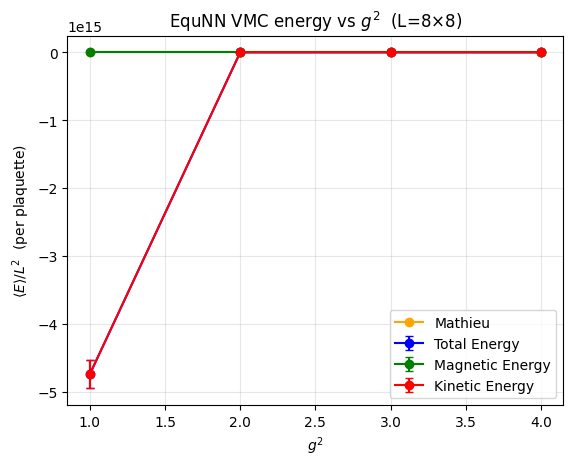

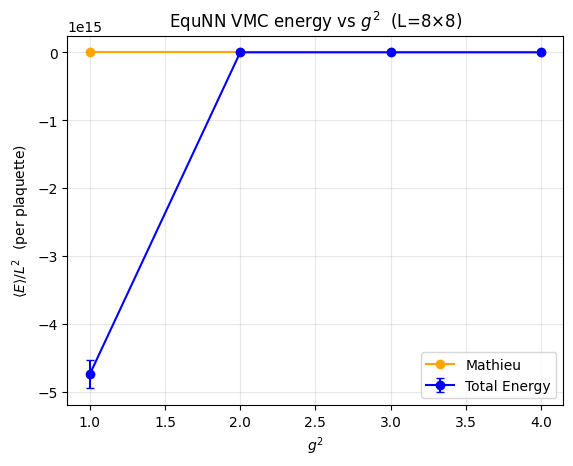

In [ ]:
from scipy.special import mathieu_a

mathieu_energy = []

g2_list = [1.0, 2.0, 3.0, 4.0]
g = np.linspace(1.0, 2.0, 100)

for g2 in g2_list:
  mathieu_energy.append(2*g2 * mathieu_a(0, -1.0/(2.0*g2**2)) + 1.0/g2)



# Plot kinetic and magnetic energy separately
# ---- plot energy ----
plt.figure()
# plt.plot(g**2, y, label=r"Analytical GS energy $E_0(g^2)$")
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.errorbar(g2_list, Emag_means, yerr=Emag_sems, fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
plt.errorbar(g2_list, Ekin_means, yerr=Ekin_sems, fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
plt.plot(g2_list, mathieu_energy, 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Only compare total energy
plt.errorbar(g2_list, Epp_means, yerr=Epp_sems, fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.plot(g2_list, mathieu_energy, 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

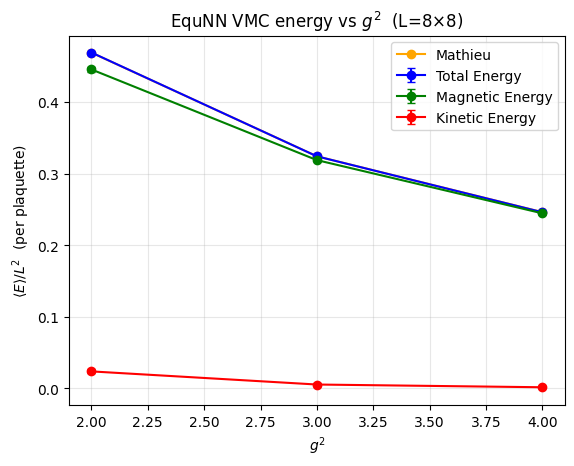

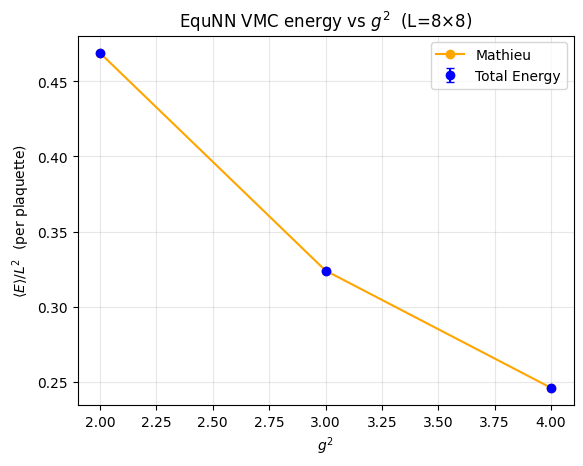

In [ ]:
# Plot kinetic and magnetic energy separately
# ---- plot energy ----
plt.figure()
# plt.plot(g**2, y, label=r"Analytical GS energy $E_0(g^2)$")
plt.errorbar(g2_list[1:], Epp_means[1:], yerr=Epp_sems[1:], fmt='o-', capsize=3, color = 'b', label='Total Energy')
plt.errorbar(g2_list[1:], Emag_means[1:], yerr=Emag_sems[1:], fmt='o-', capsize=3, color = 'g', label='Magnetic Energy')
plt.errorbar(g2_list[1:], Ekin_means[1:], yerr=Ekin_sems[1:], fmt='o-', capsize=3, color = 'r', label='Kinetic Energy')
plt.plot(g2_list[1:], mathieu_energy[1:], 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Only compare total energy
plt.errorbar(g2_list[1:], Epp_means[1:], yerr=Epp_sems[1:], fmt='o', capsize=3, color = 'b', label='Total Energy')
plt.plot(g2_list[1:], mathieu_energy[1:], 'o-', color = 'orange', label='Mathieu')

plt.xlabel(r"$g^2$")
plt.ylabel(r"$\langle E\rangle/L^2$  (per plaquette)")
plt.title(f"EquNN VMC energy vs $g^2$  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

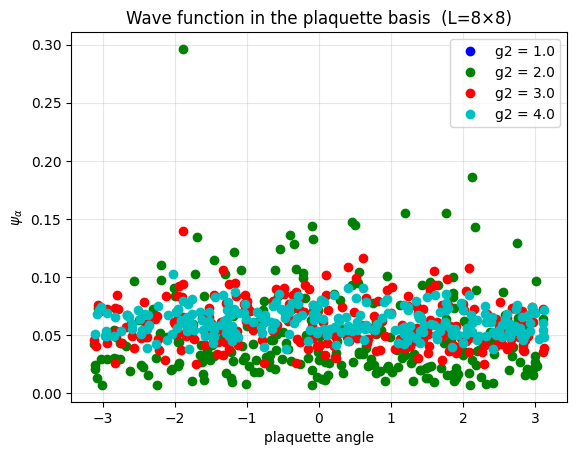

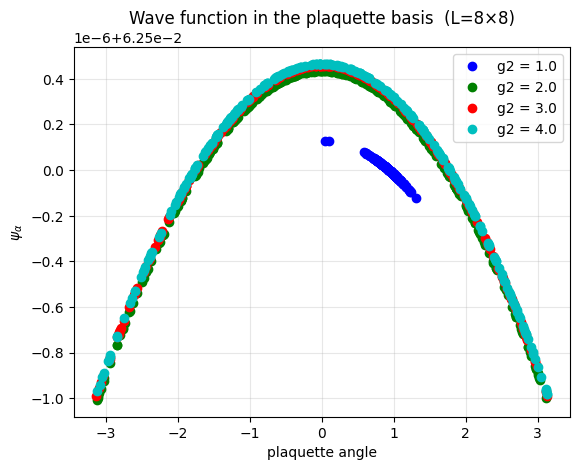

In [ ]:
# ---- plot wave function vs plaquette angle ----
plt.figure()

for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    # y_plot = normalised_mathieu
    psi = torch.exp(wave_fns[i][1])
    normalisation = torch.sqrt(torch.sum(psi **2))
    normalised_wf = psi / normalisation
    y_plot = normalised_wf.detach().cpu().numpy()

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, y_plot, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Plot the matthieu function
for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    mathieu, _ = scipy.special.mathieu_cem(0, -1/(2* g2**2), x_plot/2)
    normalised_mathieu = mathieu / np.sqrt(np.sum(mathieu **2))

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, normalised_mathieu, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

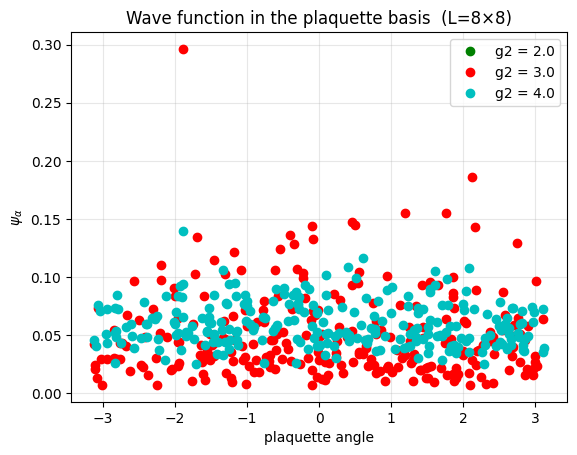

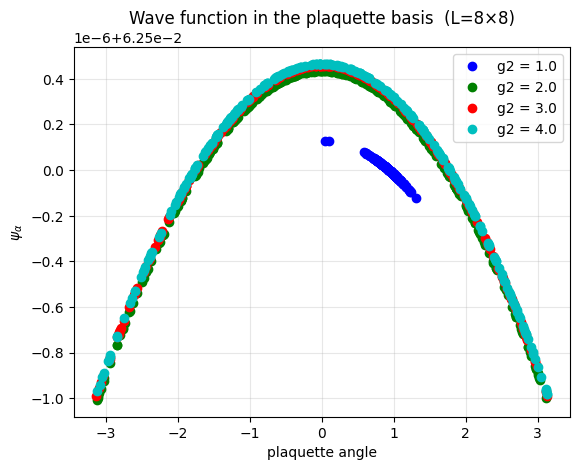

In [ ]:
# ---- plot wave function vs plaquette angle ----
plt.figure()

for i, g2_val in enumerate(g2_list[1:]):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    # y_plot = normalised_mathieu
    psi = torch.exp(wave_fns[i][1])
    normalisation = torch.sqrt(torch.sum(psi **2))
    normalised_wf = psi / normalisation
    y_plot = normalised_wf.detach().cpu().numpy()

    # Use different colors for each g2 value
    colors = ['g', 'r', 'c']
    plt.plot(x_plot, y_plot, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Plot the matthieu function
for i, g2_val in enumerate(g2_list):
    # Flatten the plaquette angles (x-axis) for plotting and apply necessary conversions
    p_angle = ((wave_fns[i][0] + TWOPI/2) % TWOPI ) - TWOPI/2
    x_plot = p_angle.flatten().detach().cpu().numpy()

    mathieu, _ = scipy.special.mathieu_cem(0, -1/(2* g2**2), x_plot/2)
    normalised_mathieu = mathieu / np.sqrt(np.sum(mathieu **2))

    # Use different colors for each g2 value
    colors = ['b', 'g', 'r', 'c']
    plt.plot(x_plot, normalised_mathieu, 'o', color=colors[i], label=f'g2 = {g2_val}')

plt.xlabel(r"plaquette angle")
plt.ylabel(r"$\psi_\alpha $")
plt.title(f"Wave function in the plaquette basis  (L={L}\u00d7{L})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()